<a href="https://colab.research.google.com/github/dianasimon760-boop/laguardiadataclass/blob/main/class29.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_style('whitegrid')

In [72]:
df = pd.read_csv("https://raw.githubusercontent.com/dianasimon760-boop/laguardiadataclass/refs/heads/main/311_Service_Requests_from_2019May.csv", low_memory=False)
df.head()

,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,City,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
0,42680103,5/1/2019 0:00,5/16/2019 21:45,DEP,Water System,NaN,11420,127-16 111 AVENUE,111 AVENUE,ADDRESS,South Ozone Park,NaN,NaN,Closed,NaN,The Department of Environment Protection inspe...,4116320006.00,QUEENS,40.68,-73.81,"(40.682565064146196, -73.81406015056832)"
1,42530481,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10011,207 WEST 14 STREET,WEST 14 STREET,ADDRESS,NEW YORK,NaN,NaN,Closed,5/15/2019 22:17,Callers should contact the DOHMH Foodborne Ill...,1007640034.00,MANHATTAN,40.74,-74.00,"(40.738790792032844, -74.00022373020307)"
2,42527619,5/1/2019 0:00,5/13/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10025,2664 BROADWAY,BROADWAY,ADDRESS,NEW YORK,NaN,NaN,Closed,5/15/2019 10:04,The Department of Health and Mental Hygiene wi...,1018730020.00,MANHATTAN,40.80,-73.97,"(40.79804015465285, -73.96930001020544)"
3,42526597,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11208,624 SOUTH CONDUIT BOULEVARD,SOUTH CONDUIT BOULEVARD,ADDRESS,BROOKLYN,NaN,NaN,Closed,5/15/2019 17:27,The Department of Health and Mental Hygiene wi...,3042380011.00,BROOKLYN,40.68,-73.87,"(40.67590510222738, -73.86665990579837)"
4,42526595,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11106,31-91 21 STREET,21 STREET,ADDRESS,Astoria,NaN,NaN,Closed,5/15/2019 17:12,The Department of Health and Mental Hygiene wi...,4005540015.00,QUEENS,40.77,-73.93,"(40.76536704921336, -73.93154011254339)"


In [59]:
# Possible file locations
candidate_paths = [
    Path("https://raw.githubusercontent.com/dianasimon760-boop/DeeDataanalytics/refs/heads/main/311_Service_Requests_from_2019May.csv?token=GHSAT0AAAAAAD3PNYE4LGDVOS4KQKCTCC3Q2PNO3ZQ"),
    #Path('/mnt/311_Service_Requests_from_2019May.csv'),
    #Path('/content/311_Service_Requests_from_2019May.csv'),
    #Path('/content/drive/MyDrive/311_Service_Requests_from_2019May.csv'),
]

file_path = None
for p in candidate_paths:
    if p.exists():
        file_path = p
        break

if file_path is None:
    raise FileNotFoundError(
        'CSV file not found. Place 311_Service_Requests_from_2019May.csv in the same folder as the notebook '
        'or update candidate_paths.'
    )

print(f'Using file: {file_path}')
df = pd.read_csv(file_path, low_memory=False)
df.head()


FileNotFoundError: CSV file not found. Place 311_Service_Requests_from_2019May.csv in the same folder as the notebook or update candidate_paths.

In [73]:
rows, cols=df.shape

In [74]:
print(f'Total Rows: {rows}')
print(f'Total Columns: {cols}')

Total Rows: 69637
Total Columns: 21


In [75]:
print('/nDatatypes:')

/nDatatypes:


In [76]:
df.dtypes

,0
Unique Key,int64
Created Date,object
Closed Date,object
Agency,object
Complaint Type,object
Location Type,object
Incident Zip,object
Incident Address,object
Street Name,object
Address Type,object


In [77]:
summary_stats = df.describe(include='all').transpose()
summary_stats

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unique Key,69637.00,NaN,NaN,NaN,42603073.66,52698.18,42512785.00,42580039.00,42600186.00,42620949.00,42973430.00
Created Date,69637,11844,5/7/2019 14:59,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Closed Date,64626,15797,5/10/2019 0:00,840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agency,69637,20,NYPD,21188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Complaint Type,69637,186,Noise - Residential,5838,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location Type,53978,98,Street/Sidewalk,13748,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Incident Zip,67389,221,11385,1213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Incident Address,59033,37426,78-15 PARSONS BOULEVARD,408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Street Name,59032,5564,BROADWAY,538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address Type,68307,5,ADDRESS,57140,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
total_missing = df.isna().sum().sum()
print(f'Total missing values in the dataset: {total_missing}')

Total missing values in the dataset: 231655


In [32]:
missing_by_column = df.isna().sum().sort_values(ascending=False).to_frame(name='Missing Values')
missing_by_column


,Missing Values
Landmark,69621
Facility Type,45556
Due Date,36798
Location Type,15659
BBL,13935
Street Name,10605
Incident Address,10604
Resolution Description,6058
Closed Date,5011
Location,4003


# Use imputation techniques to clean the data
# Strategy used:

# Numeric columns → median
# Categorical / object columns → mode

In [33]:
clean_df = df.copy()

numeric_cols = clean_df.select_dtypes(include=[np.number]).columns
categorical_cols = clean_df.select_dtypes(include=['object']).columns

# Impute numeric columns with median
for col in numeric_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Impute categorical columns with mode
for col in categorical_cols:
    mode_series = clean_df[col].mode(dropna=True)
    if not mode_series.empty:
        clean_df[col] = clean_df[col].fillna(mode_series[0])

print('Numeric columns imputed with median:')
print(list(numeric_cols))
print('\nCategorical/object columns imputed with mode:')
print(list(categorical_cols))

Numeric columns imputed with median:
['Unique Key', 'BBL', 'Latitude', 'Longitude']

Categorical/object columns imputed with mode:
['Created Date', 'Closed Date', 'Agency', 'Complaint Type', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'Borough', 'Location']


In [34]:
#Verify if the new data is fully clean
remaining_missing = clean_df.isna().sum().sum()
print(f'Remaining missing values after imputation: {remaining_missing}')

clean_df.isna().sum().sort_values(ascending=False)


Remaining missing values after imputation: 0


,0
Unique Key,0
Created Date,0
Closed Date,0
Agency,0
Complaint Type,0
Location Type,0
Incident Zip,0
Incident Address,0
Street Name,0
Address Type,0


In [35]:
#Apply a filter to one column
#Example filter: show only rows where Borough = BROOKLYN
brooklyn_df = clean_df[clean_df['Borough'] == 'BROOKLYN']
print(f'Number of rows after filtering Borough = BROOKLYN: {brooklyn_df.shape[0]}')
brooklyn_df.head()

Number of rows after filtering Borough = BROOKLYN: 22247


,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,City,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
3,42526597,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11208,624 SOUTH CONDUIT BOULEVARD,SOUTH CONDUIT BOULEVARD,ADDRESS,BROOKLYN,CENTRAL PARK,Precinct,Closed,5/15/2019 17:27,The Department of Health and Mental Hygiene wi...,3.042380e+09,BROOKLYN,40.675905,-73.866660,"(40.67590510222738, -73.86665990579837)"
10,42613472,5/1/2019 0:00,5/10/2019 0:00,DEP,FATF,Street/Sidewalk,11222,329 GREENPOINT AVENUE,GREENPOINT AVENUE,ADDRESS,BROOKLYN,CENTRAL PARK,Precinct,Started,6/14/2019 18:04,The Department of Environmental Protection has...,3.025250e+09,BROOKLYN,40.731483,-73.946271,"(40.73148270284829, -73.94627094704092)"
11,42524126,5/1/2019 0:00,5/3/2019 1:45,DEP,Noise,Street/Sidewalk,11226,601 MARLBOROUGH ROAD,MARLBOROUGH ROAD,ADDRESS,BROOKLYN,CENTRAL PARK,Precinct,Closed,6/14/2019 18:04,The Department of Environmental Protection did...,3.052360e+09,BROOKLYN,40.635299,-73.963300,"(40.63529885534431, -73.96330029572755)"
16,42514390,5/1/2019 0:01,5/1/2019 0:43,NYPD,Noise - Residential,Residential Building/House,11216,223 MADISON STREET,MADISON STREET,ADDRESS,BROOKLYN,CENTRAL PARK,Precinct,Closed,5/1/2019 8:01,The Police Department responded to the complai...,3.018180e+09,BROOKLYN,40.684829,-73.949698,"(40.68482875564692, -73.94969783222867)"
19,42523573,5/1/2019 0:02,5/1/2019 0:02,DOB,General Construction/Plumbing,Street/Sidewalk,11222,2 BLUE SLIP,BLUE SLIP,ADDRESS,BROOKLYN,CENTRAL PARK,Precinct,Closed,6/14/2019 18:04,The Department of Buildings attempted to inves...,3.034830e+09,BROOKLYN,40.735548,-73.959792,"(40.73554770947688, -73.95979186450654)"


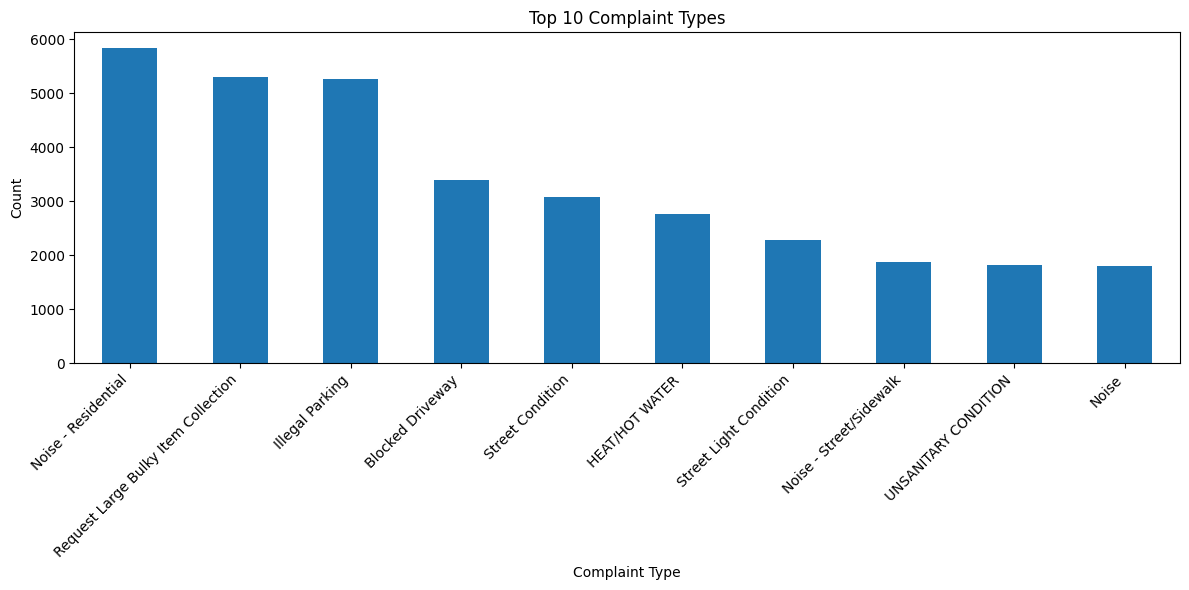

In [36]:
# Create 3 visualizations # Visualization 1: Top 10 complaint types
top_complaints = clean_df['Complaint Type'].value_counts().head(10) #name x axis complaint type show first 10 complaints

plt.figure(figsize=(12, 6)) #size
top_complaints.plot(kind='bar') #type of graph
plt.title('Top 10 Complaint Types') #head title at the tope
plt.xlabel('Complaint Type') #xlable  complaint type
plt.ylabel('Count') #y label it count
plt.xticks(rotation=45, ha='right') #
plt.tight_layout()
plt.show()


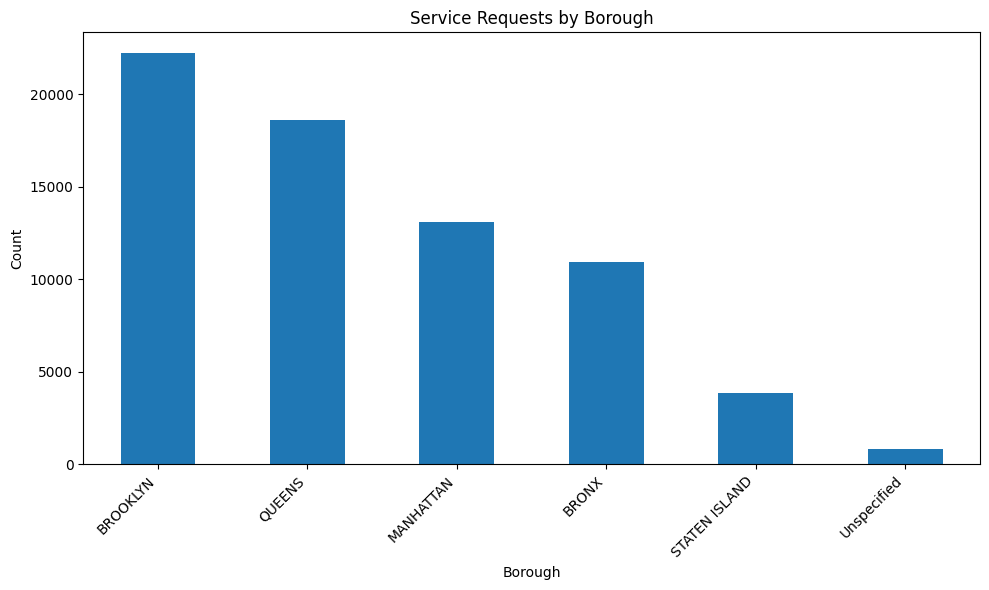

In [37]:
# Visualization 2: Borough-wise service request count
borough_counts = clean_df['Borough'].value_counts()

plt.figure(figsize=(10, 6))
borough_counts.plot(kind='bar')
plt.title('Service Requests by Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

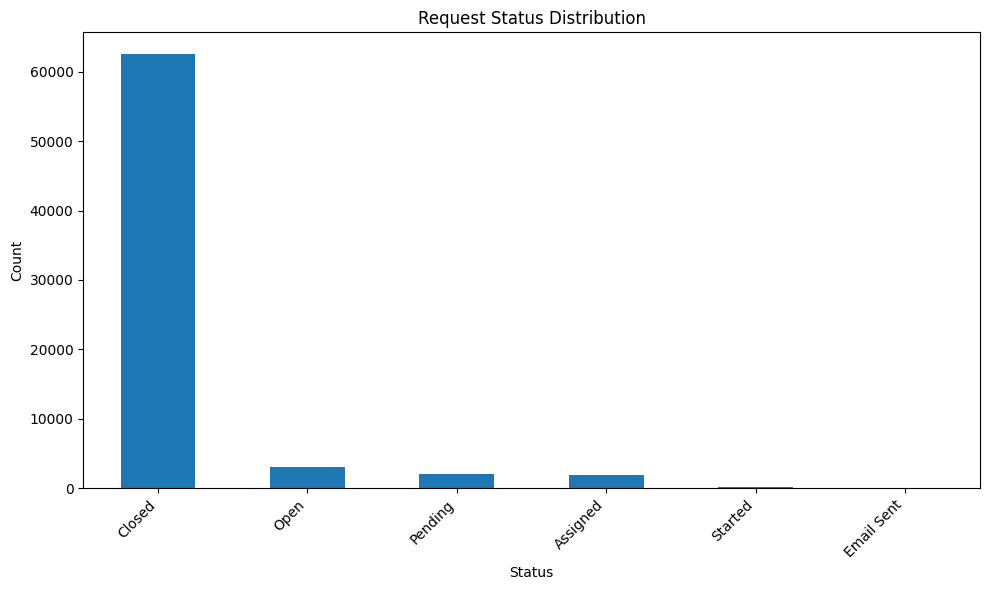

In [38]:
# Visualization 3: Status distribution
status_counts = clean_df['Status'].value_counts()

plt.figure(figsize=(10, 6))
status_counts.plot(kind='bar')
plt.title('Request Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [39]:
output_file = '311_Service_Requests_from_2019May_cleaned.csv'
clean_df.to_csv(output_file, index=False)
print(f'Cleaned dataset saved as: {output_file}')


Cleaned dataset saved as: 311_Service_Requests_from_2019May_cleaned.csv


In [40]:
summary_stats1 = clean_df.describe(include='all').transpose()
summary_stats1

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unique Key,69637.0,NaN,NaN,NaN,42603073.663412,52698.184066,42512785.0,42580039.0,42600186.0,42620949.0,42973430.0
Created Date,69637,11844,5/7/2019 14:59,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Closed Date,69637,15797,5/10/2019 0:00,5851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agency,69637,20,NYPD,21188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Complaint Type,69637,186,Noise - Residential,5838,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location Type,69637,98,Street/Sidewalk,29407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Incident Zip,69637,221,11385,3461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Incident Address,69637,37426,78-15 PARSONS BOULEVARD,11012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Street Name,69637,5564,BROADWAY,11143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address Type,69637,5,ADDRESS,58470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
